# Breadth First Search (BFS)

Breadth First Search (BFS) is an uninformed search algorithm that explores the environment level by level.

In this Flood Evacuation & Rescue System, BFS is used to find the shortest path from the rescue team's starting position to a victim while avoiding buildings, blocked roads, and flooded cells.

### Advantages
- Guarantees the shortest path when all moves have equal cost.
- Simple to implement.
- Suitable as a baseline pathfinding algorithm.

### Limitations
- Does not consider flood severity or movement cost.
- May explore many unnecessary cells.

# Complete Rescue Operation using BFS

In this simulation, BFS is used in two phases:

1. Find the shortest path from the Rescue Team to the Victim.
2. Find the shortest path from the Victim to the Shelter.

The two paths are combined to represent a complete rescue operation.

Rescue Team → Victim → Shelter

In [1]:
%matplotlib inline
from collections import deque
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

sys.path.append(os.path.abspath(".."))

from Environment.grid import *


VICTIM:
[(18, 6), (17, 8), (15, 10)]

SHELTER:
(18, 18)

FLOOD ORIGINS:
[(9, 9), (9, 10), (10, 9), (10, 10), (11, 9), (11, 10), (12, 9), (12, 10), (15, 8), (15, 9), (16, 8), (16, 9), (17, 8), (17, 9)]

NEIGHBORS OF VICTIM:
(18, 6): [(17, 6), (19, 6), (18, 5), (18, 7)]
(17, 8): [(18, 8), (17, 7), (17, 9)]
(15, 10): [(14, 10), (16, 10), (15, 9), (15, 11)]

CELL INFO (9,9):
{'type': 2, 'water_level': 0.55, 'passable': True}

MOVEMENT COST OF (8,8):
1.0

IS (3,3) PASSABLE?
False


# BFS Algorithm Implementation

The BFS algorithm explores neighboring cells level by level.

A queue is used to store cells that need to be explored.

A parent dictionary is maintained so that once the victim is found, the complete path can be reconstructed.

In [2]:
def bfs(start, goal):

    queue = deque()
    queue.append(start)

    visited = set()
    visited.add(start)

    parent = {}
    parent[start] = None

    while queue:

        current = queue.popleft()

        if current == goal:

            path = []
            node = current

            while node is not None:
                path.append(node)
                node = parent[node]

            path.reverse()

            return path

        for neighbor in get_neighbors(current):

            if neighbor not in visited:

                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)

    return None

In [3]:
def bfs_multi_goal(start, goals):

    queue = deque()
    queue.append(start)

    visited = set()
    visited.add(start)

    parent = {}
    parent[start] = None

    goal_set = set(goals)

    while queue:

        current = queue.popleft()

        if current in goal_set:

            path = []
            node = current

            while node is not None:
                path.append(node)
                node = parent[node]

            path.reverse()

            return path, current

        for neighbor in get_neighbors(current):

            if neighbor not in visited:

                visited.add(neighbor)
                parent[neighbor] = current
                queue.append(neighbor)

    return None, None

# Rescue Team Start Position

The rescue team begins from the top-left corner of the environment grid.

The objective is to locate and reach a victim using BFS.

In [4]:
start = (0, 0)

# Victims multiple hain -> multi-goal BFS
path_to_victim, found_victim = bfs_multi_goal(start, victims)

# Shelter single hai -> normal BFS
path_to_shelter = bfs(found_victim, shelter)

if path_to_victim and path_to_shelter:
    full_path = path_to_victim + path_to_shelter[1:]
    print("Nearest Victim:", found_victim)
    print("Path to Victim:", len(path_to_victim)-1, "steps")
    print("Path to Shelter:", len(path_to_shelter)-1, "steps")
    print("Total Rescue Path:", len(full_path)-1, "steps")
else:
    print("No valid rescue path found.")

Nearest Victim: (18, 6)
Path to Victim: 24 steps
Path to Shelter: 12 steps
Total Rescue Path: 36 steps


# Execute BFS Search

The BFS algorithm is executed to find the shortest path from the rescue team to the victim.

After finding the victim, the path is reconstructed and displayed.

In [5]:
path_to_victim, found_victim = bfs_multi_goal(start, victims)
path_to_shelter = bfs(found_victim, shelter)

if path_to_victim:
    print("Path Found!")
    print()
    for p in path_to_victim:
        print(p)
    print()
    print("Total Steps:", len(path_to_victim)-1)
else:
    print("No Path Found!")

if path_to_shelter:
    print("Path Found!")
    print()
    for p in path_to_shelter:
        print(p)
    print()
    print("Total Steps:", np.sum([len(path_to_shelter)-1, len(path_to_victim)-1]))

Path Found!

(0, 0)
(1, 0)
(2, 0)
(3, 0)
(4, 0)
(5, 0)
(6, 0)
(7, 0)
(8, 0)
(9, 0)
(10, 0)
(11, 0)
(12, 0)
(13, 0)
(14, 0)
(15, 0)
(16, 0)
(17, 0)
(18, 0)
(18, 1)
(18, 2)
(18, 3)
(18, 4)
(18, 5)
(18, 6)

Total Steps: 24
Path Found!

(18, 6)
(18, 7)
(18, 8)
(18, 9)
(18, 10)
(18, 11)
(18, 12)
(18, 13)
(18, 14)
(18, 15)
(18, 16)
(18, 17)
(18, 18)

Total Steps: 36


# Rescue Movement Simulation

To visualize the rescue operation, the rescue team moves step-by-step along the path generated by BFS.

The simulation updates the rescue team's position at each time step until the victim is reached.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from Environment.grid import *

def show_snapshot(title):

    # reuse SAME function style (no recoloring)
    display_grid(save_image=False)

    plt.title(title)
    plt.show()

# Run Rescue Simulation

The rescue team follows the path discovered by BFS and moves toward the victim one step at a time.

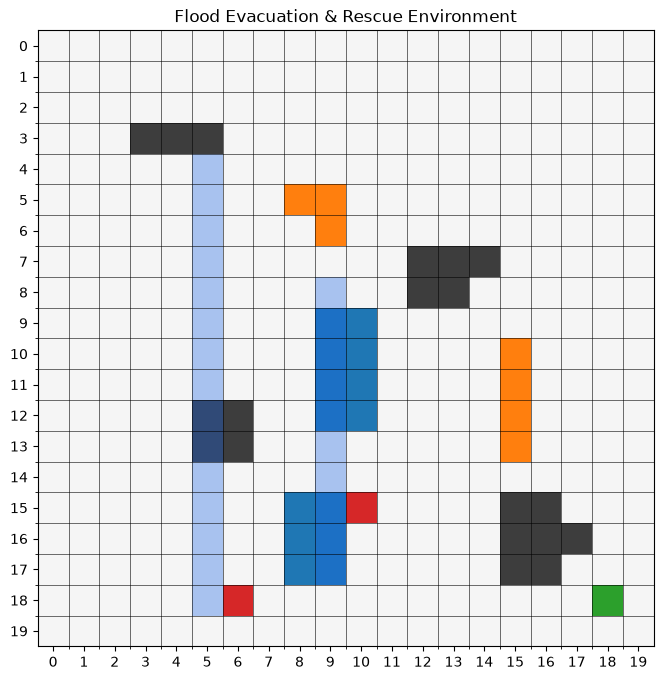

In [7]:
display_grid(save_image=False)


PATH TO VICTIM:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (15, 0), (16, 0), (17, 0), (18, 0), (18, 1), (18, 2), (18, 3), (18, 4), (18, 5), (18, 6)]

Image Saved: stage2_victim_found_BFS.png


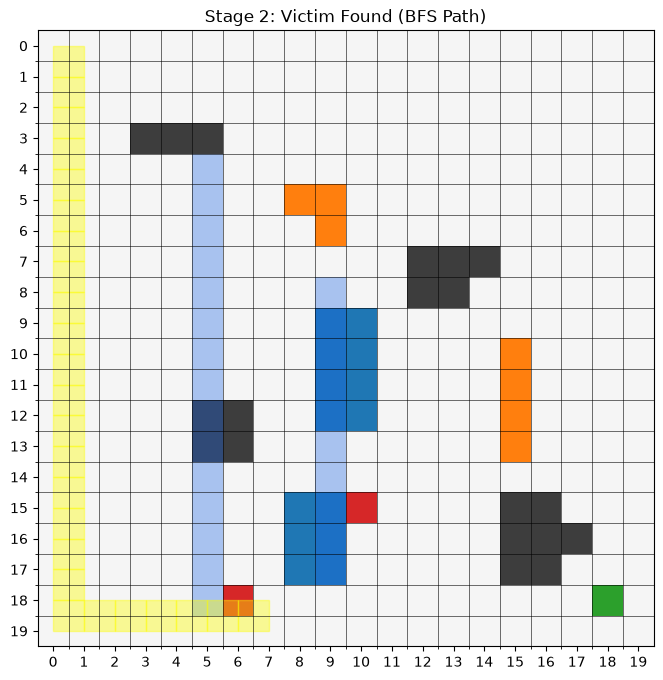

In [8]:
# =====================================================
# STAGE 2: BFS PATH TO VICTIM
# =====================================================

def display_path_to_victim(path_to_victim, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    # ==========================================
    # RISKY CELL OVERLAY
    # ==========================================

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    # ==========================================
    # HIGHLIGHT BFS PATH
    # ==========================================

    for r, c in path_to_victim:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="yellow",
                alpha=0.4
            )
        )

    # ==========================================
    # GRID LINES
    # ==========================================

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 2: Victim Found (BFS Path)"
    )

    # ==========================================
    # SAVE IMAGE FOR GITHUB
    # ==========================================

    if save_image:

        plt.savefig(
            "../images/stage2_victim_found_BFS.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: stage2_victim_found_BFS.png"
        )

    plt.show()
path_to_victim, found_victim = bfs_multi_goal(start, victims)
print("\nPATH TO VICTIM:")
print(path_to_victim)

display_path_to_victim(path_to_victim)


FULL RESCUE PATH:
[(0, 0), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0), (8, 0), (9, 0), (10, 0), (11, 0), (12, 0), (13, 0), (14, 0), (15, 0), (16, 0), (17, 0), (18, 0), (18, 1), (18, 2), (18, 3), (18, 4), (18, 5), (18, 6), (18, 7), (18, 8), (18, 9), (18, 10), (18, 11), (18, 12), (18, 13), (18, 14), (18, 15), (18, 16), (18, 17), (18, 18)]

Image Saved: stage3_full_rescue_BFS.png


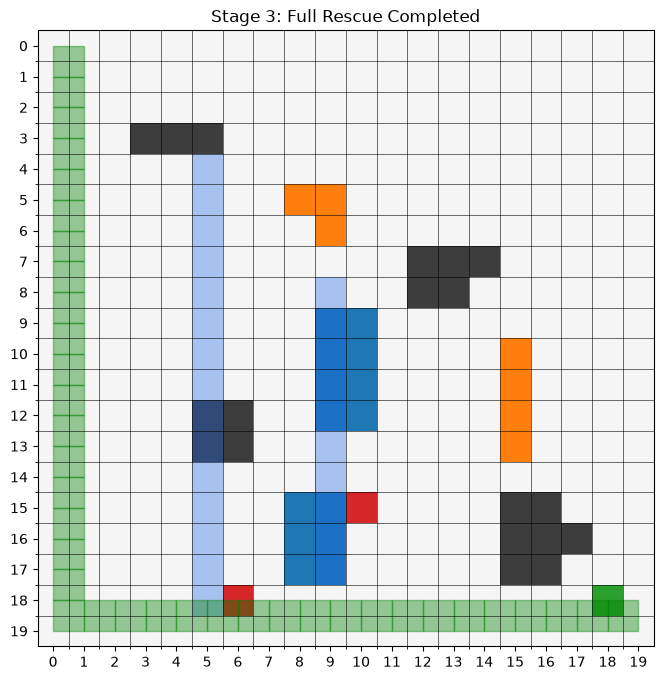

In [9]:
# =====================================================
# STAGE 3: FULL RESCUE PATH (VICTIM TO SHELTER)
# =====================================================

def display_full_rescue_path(full_path, save_image=True):

    colors = [
        "#f5f5f5",  # ROAD
        "#3d3d3d",  # BUILDING
        "#1f77b4",  # FLOOD
        "#ff7f0e",  # BLOCKED
        "#d62728",  # VICTIM
        "#2ca02c"   # SHELTER
    ]

    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(8,8))

    ax.imshow(
        cell_type,
        cmap=cmap,
        vmin=0,
        vmax=5
    )

    # ==========================================
    # RISKY CELL OVERLAY
    # ==========================================

    overlay = np.zeros((ROWS, COLS, 4))

    for r in range(ROWS):
        for c in range(COLS):

            if (
                RISKY_THRESHOLD
                <
                water_level[r][c]
                <=
                FLOOD_THRESHOLD
            ):

                overlay[r][c] = [
                    0.1,
                    0.4,
                    0.9,
                    0.35
                ]

    ax.imshow(overlay)

    # ==========================================
    # HIGHLIGHT FULL PATH
    # ==========================================

    for r, c in full_path:

        ax.add_patch(
            plt.Rectangle(
                (c, r),
                1,
                1,
                color="green",
                alpha=0.4
            )
        )

    # ==========================================
    # GRID LINES
    # ==========================================

    ax.set_xticks(range(COLS))
    ax.set_yticks(range(ROWS))

    ax.set_xticks(
        [x - 0.5 for x in range(1, COLS)],
        minor=True
    )

    ax.set_yticks(
        [y - 0.5 for y in range(1, ROWS)],
        minor=True
    )

    ax.grid(
        which="minor",
        color="black",
        linewidth=0.4
    )

    ax.set_title(
        "Stage 3: Full Rescue Completed"
    )

    # ==========================================
    # SAVE IMAGE FOR GITHUB
    # ==========================================

    if save_image:

        plt.savefig(
            "../images/stage3_full_rescue_BFS.png",
            bbox_inches="tight"
        )

        print(
            "\nImage Saved: stage3_full_rescue_BFS.png"
        )

    plt.show()
path_to_shelter = bfs(found_victim, shelter)
full_path = path_to_victim + path_to_shelter[1:]

print("\nFULL RESCUE PATH:")
print(full_path)

display_full_rescue_path(full_path)

In [10]:
reset_grid()